# DEMO - Testing and Training HerdNet on nadir aerial images

## Setup

For setup instructions see: doc/setup.md in the repository.


In [1]:
# Check if a GPU is available
!nvidia-smi

Wed Feb  4 12:28:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.05             Driver Version: 550.127.05     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        On  |   00000000:61:00.0 Off |                  Off |
|  0%   34C    P8             20W /  450W |       2MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
## If an old GPU like GTX 1080 is available install older torch version which is compatible
# !pip uninstall -y torch torchvision torchaudio
#
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [ ]:
# Download and install the code
import sys

!git clone -b main https://github.com/cwinkelmann/HerdNet
!cd HerdNet && git pull
!pip install -e ./HerdNet


sys.path.append('./HerdNet')
sys.path.append('./HerdNet/tools')

In [ ]:
from loguru import logger

logger.disable("animaloc")

# !unzip -oq ./data.zip -d ./

## Download Models and Demo Datasets

Data and Models are hosted on Huggingface, see:

https://huggingface.co/karisu/HerdNet
and
https://huggingface.co/datasets/karisu/General_Dataset 

In [5]:
from huggingface_hub import hf_hub_download
from pathlib import Path
local_dir = Path("./models").resolve()

# Download specific files
model_path = hf_hub_download(
    repo_id="karisu/HerdNet",
    filename="general_2022/20220413_HerdNet_General_dataset_2022.pth",  # adjust filename as needed
    local_dir=local_dir
)

config_path = hf_hub_download(
    repo_id="karisu/HerdNet",
    filename="general_2022/config.yaml",
    local_dir=local_dir
)

print(f"Model Path: {model_path} and Config Path: {config_path}")

Model Path: /workspace/models/general_2022/20220413_HerdNet_General_dataset_2022.pth and Config Path: /workspace/models/general_2022/config.yaml


Load a seperate Sample of the test set

In [44]:
from huggingface_hub import snapshot_download

# load a small sample of the testset
sample_data_path = snapshot_download(
    repo_id="karisu/General_Dataset",
    repo_type="dataset",
    local_dir="./data",
    allow_patterns=["test_sample/*"],  # multiple folders
    revision="main",                        # branch/tag/commit
)
sample_data_path

test_sample_annotation_path = hf_hub_download(
    repo_id="karisu/General_Dataset",
    repo_type="dataset",
    filename="test_sample.csv",  # specify the file path within the repo
    local_dir="./data",
)

Fetching ... files: 0it [00:00, ?it/s]

test_sample.csv: 0.00B [00:00, ?B/s]

### Create the Helper Functions


In [7]:
# Test installation
# Set the seed
from animaloc.utils.seed import set_seed

set_seed(9292)

# Warning: If you receive an error here , restart the Kernel and rerun the full notebook
## If the error persists, then execute the following commands.
##
#!pip install wandb --upgrade
#!pip install --upgrade --force-reinstall typing_extensions
##

In [8]:
# Training, validation and test datasets
import albumentations as A

from animaloc.datasets import CSVDataset
from animaloc.data.transforms import MultiTransformsWrapper, DownSample, PointsToMask, FIDT

patch_size = 512
num_classes = 7
down_ratio = 2



test_dataset = CSVDataset(
    csv_file = './data/test_sample.csv',
    root_dir = './data/test_sample',
    albu_transforms = [A.Normalize(p=1.0)],
    end_transforms = [DownSample(down_ratio=down_ratio, anno_type='point')]
    )

In [9]:
# Dataloaders
from torch.utils.data import DataLoader

test_dataloader = DataLoader(dataset = test_dataset, batch_size = 1, shuffle = False)

The Loss Wrapper is needed to evaluate the model against a known test-set

In [10]:
from animaloc.models import HerdNet
from torch import Tensor
from animaloc.models import LossWrapper
from animaloc.train.losses import FocalLoss
from torch.nn import CrossEntropyLoss

herdnet = HerdNet(num_classes=num_classes, down_ratio=down_ratio).cuda()

weight = Tensor([0.1, 1.0, 2.0, 1.0, 6.0, 12.0, 1.0]).cuda()

losses = [
    {'loss': FocalLoss(reduction='mean'), 'idx': 0, 'idy': 0, 'lambda': 1.0, 'name': 'focal_loss'},
    {'loss': CrossEntropyLoss(reduction='mean', weight=weight), 'idx': 1, 'idy': 1, 'lambda': 1.0, 'name': 'ce_loss'}
    ]

## This loss Wrapper is important for the Evaluator even if there will be no Training
herdnet = LossWrapper(herdnet, losses=losses)

The Stitcher allows for inference on images larger than 512px

In [11]:
from torch.optim import Adam
from animaloc.train import Trainer
from animaloc.eval import PointsMetrics, HerdNetStitcher, HerdNetEvaluator
from animaloc.utils.useful_funcs import mkdir

work_dir = './output'
mkdir(work_dir)



optimizer = Adam(params=herdnet.parameters(), lr=lr, weight_decay=weight_decay)

metrics = PointsMetrics(radius=20, num_classes=num_classes)

stitcher = HerdNetStitcher(
    model=herdnet,
    size=(patch_size,patch_size),
    overlap=160,
    down_ratio=down_ratio,
    reduction='mean'
    )



## Running HerdNet

At first a pretrained model is run against the Test Subset on African Megafauna.
Then it shown how to train the model.


### Test the pretrained model

A downloaded model is run against a small data.

In [ ]:

# Load trained parameters
from animaloc.models import load_model
pth_path = './models/general_2022/20220413_HerdNet_General_dataset_2022.pth'

herdnet = load_model(herdnet, pth_path=pth_path)
herdnet = LossWrapper(herdnet, losses=losses)

In [13]:
# Create output folder
test_dir = './test_output'
mkdir(test_dir)

In [14]:
# Create an Evaluator
test_evaluator = HerdNetEvaluator(
    model=herdnet,
    dataloader=test_dataloader,
    metrics=metrics,
    stitcher=stitcher,
    work_dir=test_dir,
    header='test'
    )

In [15]:
# Start testing
test_f1_score = test_evaluator.evaluate(returns='f1_score')

test [1/7] eta: 0:00:45 n: 11 tp: 1 fp: 2 fn: 8 recall: 0.11 precision: 0.33 f1_score: 0.17 f2_score: 0.13 f5_score: 0.11 MAE: 6.0 ME: 0.0 MSE: 36.0 RMSE: 6.0 avg_score: 0.01 avg_dscore: 0.083 time: 6.4510 data: 0.5609 max mem: 1265
test [7/7] eta: 0:00:06 n: 13 tp: 7 fp: 1 fn: 5 recall: 0.58 precision: 0.88 f1_score: 0.7 f2_score: 0.63 f5_score: 0.59 MAE: 4.0 ME: 0.0 MSE: 16.0 RMSE: 4.0 avg_score: 0.83 avg_dscore: 0.22 time: 6.3047 data: 0.6576 max mem: 1419
test Total time: 0:00:44 (6.3052 s / it)


In [16]:
# Print global F1 score (%)
print(f"F1 score = {test_f1_score * 100:0.0f}%")


F1 score = 62%


In [17]:
# Get the detections
detections = test_evaluator.results
detections

,class,n,recall,precision,f1_score,confusion,mae,me,mse,rmse,ap
0,1,0,0.000000,0.00000,0.000000,1.0,0.000000,0.000000,0.000000,0.0000,0.000000
1,2,0,0.000000,0.00000,0.000000,1.0,0.000000,0.000000,0.000000,0.0000,0.000000
2,3,0,0.000000,0.00000,0.000000,1.0,0.000000,0.000000,0.000000,0.0000,0.000000
3,4,0,0.000000,0.00000,0.000000,1.0,0.000000,0.000000,0.000000,0.0000,0.000000
4,5,0,0.000000,0.00000,0.000000,1.0,0.000000,0.000000,0.000000,0.0000,0.000000
5,6,41,0.560976,0.69697,0.621622,0.0,2.285714,-1.142857,8.571429,2.9277,0.530441
6,binary,41,0.560976,0.69697,0.621622,0.0,2.285714,0.000000,8.571429,2.9277,0.530441


## Inferencing using a config file
Here just the model and configuration is loaded making the process transferable. Any config can be overridden.

In [18]:

from pathlib import Path
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf

# Clear any previous Hydra state (important in notebooks when re-running cells)
GlobalHydra.instance().clear()

# Configure paths
config_dir = str(Path.cwd() / "models/general_2022")  # adjust as needed
config_name = "config"

# Load config
with initialize_config_dir(config_dir=config_dir, version_base="1.1"):
    cfg = compose(config_name=config_name, overrides=[
        # Add any overrides here, e.g.:
        # "training.epochs=10",
        #  "training.batch_size=4",
        "model.load_from=./models/general_2022/20220413_HerdNet_General_dataset_2022.pth",
        "datasets.test.root_dir=./data/test_sample/"
    ])

# Inspect config (optional) It contains all which was used for training
print(OmegaConf.to_yaml(cfg))

losses:
  FocalLoss:
    print_name: focal_loss
    from_torch: false
    output_idx: 0
    target_idx: 0
    lambda_const: 1.0
    kwargs:
      alpha: 2
      beta: 4
      reduction: mean
      normalize: false
  CrossEntropyLoss:
    print_name: ce_loss
    from_torch: true
    output_idx: 1
    target_idx: 1
    lambda_const: 1.0
    background_class_weight: 0.1
    kwargs:
      reduction: mean
      weight:
      - ${losses.CrossEntropyLoss.background_class_weight}
      - 1.0
      - 2.0
      - 1.0
      - 6.0
      - 12.0
      - 1.0
datasets:
  img_size:
  - 512
  - 512
  anno_type: point
  num_classes: 7
  collate_fn: null
  class_def:
    1: Alcelaphinae
    2: Buffalo
    3: Kob
    4: Warthog
    5: Waterbuck
    6: Elephant
  train:
    name: CSVDataset
    csv_file: /raid/cwinkelmann/training_data/iguana/2025_12_02/last_run/train/herdnet_format_800_160_crops.csv
    root_dir: /raid/cwinkelmann/training_data/iguana/2025_12_02/last_run/train/crops_800_numNone_overlap160


In [19]:
from animaloc.utils.inference import inference

# Run inference
detections = inference(cfg, plain_inference=True, vis_detections=True)



/workspace/./HerdNet/animaloc/models/utils.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(pth_path, map_location=map_location)


[TEST] [1/7] eta: 0:00:39 n: 10 tp: 0 fp: 9 fn: 1 recall: 0.0 precision: 0.0 f1_score: 0.0 f2_score: 0.0 f5_score: 0.0 MAE: 8.0 ME: -1.0 MSE: 64.0 RMSE: 8.0 avg_score: 0.9 avg_dscore: 0.226 time: 5.6839 data: 0.6784 max mem: 1419
[TEST] [7/7] eta: 0:00:05 n: 1 tp: 0 fp: 0 fn: 1 recall: 0.0 precision: 0.0 f1_score: 0.0 f2_score: 0.0 f5_score: 0.0 MAE: 1.0 ME: -7.0 MSE: 1.0 RMSE: 1.0 avg_score: 0.0 avg_dscore: 0.0 time: 5.7529 data: 0.6631 max mem: 1419
[TEST] Total time: 0:00:40 (5.7536 s / it)


/workspace/./HerdNet/animaloc/eval/metrics.py:338: RuntimeWarning: invalid value encountered in divide
  recalls = sorted_table[:,2] / n_gt


In [20]:
# Show results
print(f"Total detections: {len(detections)}")
detections.head(10)

Total detections: 39


,images,labels,scores,dscores,x,y,count_1,count_2,count_3,count_4,count_5,count_6,species
0,018f5ab5b7516a47ff2ac48a9fc08353b533c30f.jpeg,6.0,0.983440,0.287194,1720.0,656.0,0,0,0,0,0,9,Elephant
1,018f5ab5b7516a47ff2ac48a9fc08353b533c30f.jpeg,6.0,0.544860,0.118193,3072.0,1144.0,0,0,0,0,0,9,Elephant
2,018f5ab5b7516a47ff2ac48a9fc08353b533c30f.jpeg,6.0,0.991655,0.325387,934.0,1530.0,0,0,0,0,0,9,Elephant
3,018f5ab5b7516a47ff2ac48a9fc08353b533c30f.jpeg,6.0,0.986201,0.309380,2190.0,1754.0,0,0,0,0,0,9,Elephant
4,018f5ab5b7516a47ff2ac48a9fc08353b533c30f.jpeg,6.0,0.999381,0.241297,1872.0,1782.0,0,0,0,0,0,9,Elephant
5,018f5ab5b7516a47ff2ac48a9fc08353b533c30f.jpeg,6.0,0.994207,0.220145,1286.0,1866.0,0,0,0,0,0,9,Elephant
6,018f5ab5b7516a47ff2ac48a9fc08353b533c30f.jpeg,6.0,0.998016,0.296825,2144.0,2026.0,0,0,0,0,0,9,Elephant
7,018f5ab5b7516a47ff2ac48a9fc08353b533c30f.jpeg,6.0,0.980551,0.125356,1490.0,2038.0,0,0,0,0,0,9,Elephant
8,018f5ab5b7516a47ff2ac48a9fc08353b533c30f.jpeg,6.0,0.646645,0.110413,2700.0,2392.0,0,0,0,0,0,9,Elephant
9,02e306916552df0dfe01fa352590ebb5f2a8b8ab.jpeg,6.0,0.190980,0.066239,1862.0,1946.0,0,0,0,0,0,4,Elephant


### Visualise detections

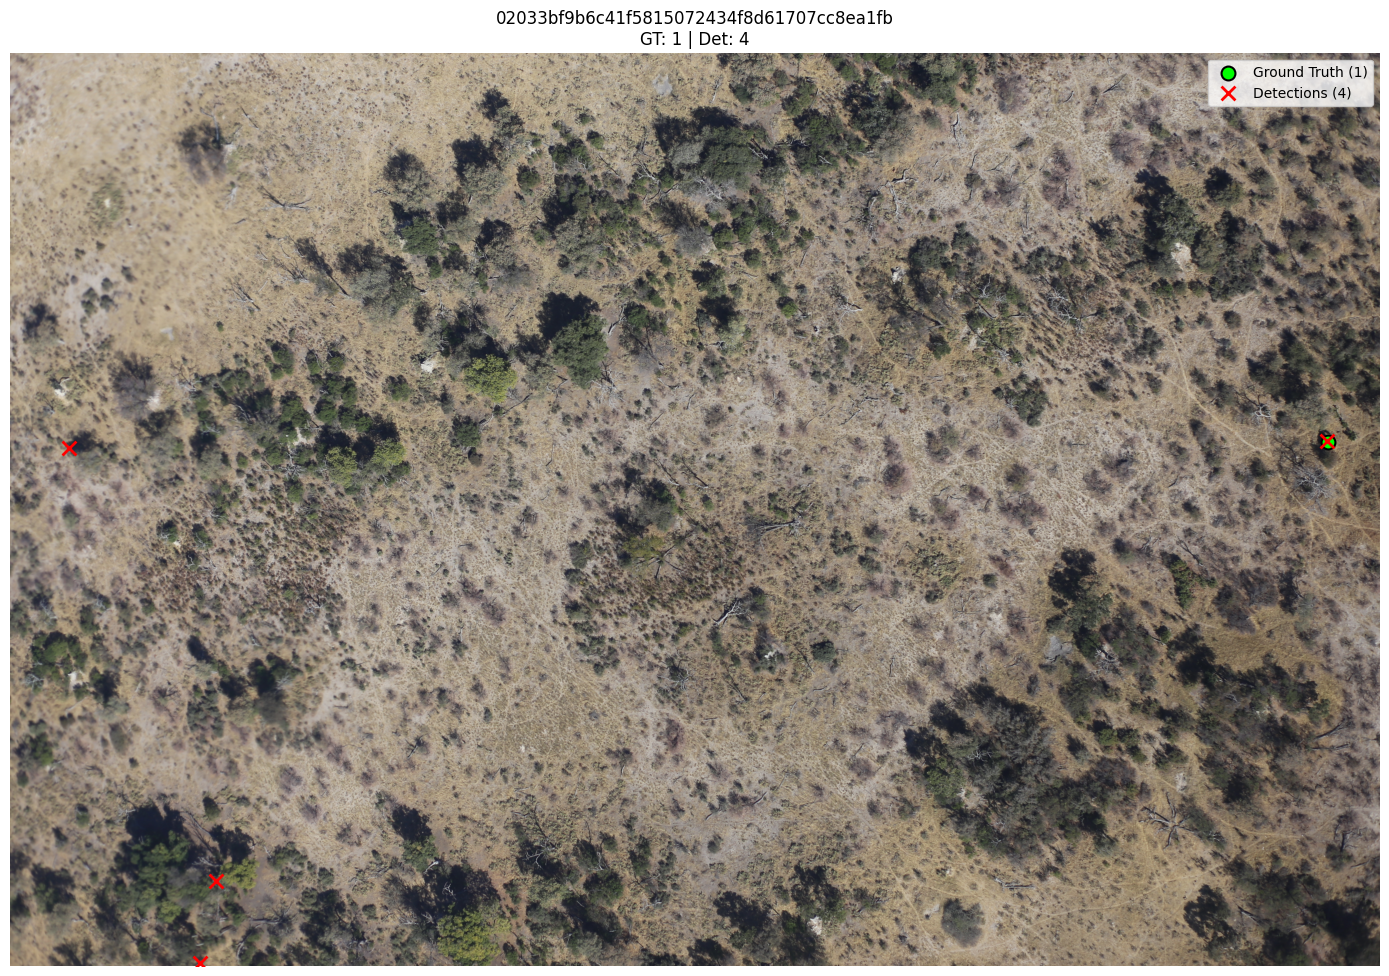

In [21]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Load data
gt_df = pd.read_csv("data/test_sample.csv")
det_df = pd.read_csv("detections.csv")

# First image
image_stem = "02033bf9b6c41f5815072434f8d61707cc8ea1fb"
image_path = f"data/test_sample/{image_stem}.jpeg"

# Get ground truth annotations (handle .JPG extension in CSV)
gt = gt_df[gt_df["images"].str.startswith(image_stem)]

# Get detections
det = det_df[det_df["images"] == f"{image_stem}.jpeg"].dropna(subset=["x", "y"])

# Plot
img = Image.open(image_path)
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(img)

# Ground truth in green
ax.scatter(gt["x"], gt["y"], c="lime", s=100, marker="o", 
           edgecolors="black", linewidths=1.5, label=f"Ground Truth ({len(gt)})")

# Detections in red
ax.scatter(det["x"], det["y"], c="red", s=100, marker="x", 
           linewidths=2, label=f"Detections ({len(det)})")

ax.set_title(f"{image_stem}\nGT: {len(gt)} | Det: {len(det)}")
ax.legend(loc="upper right")
ax.axis("off")
plt.tight_layout()
plt.savefig("detection_plot.png", dpi=150, bbox_inches="tight")


#### Looking into single predictions
Those are with a reasonably high confidence Score.

Found 2 thumbnails


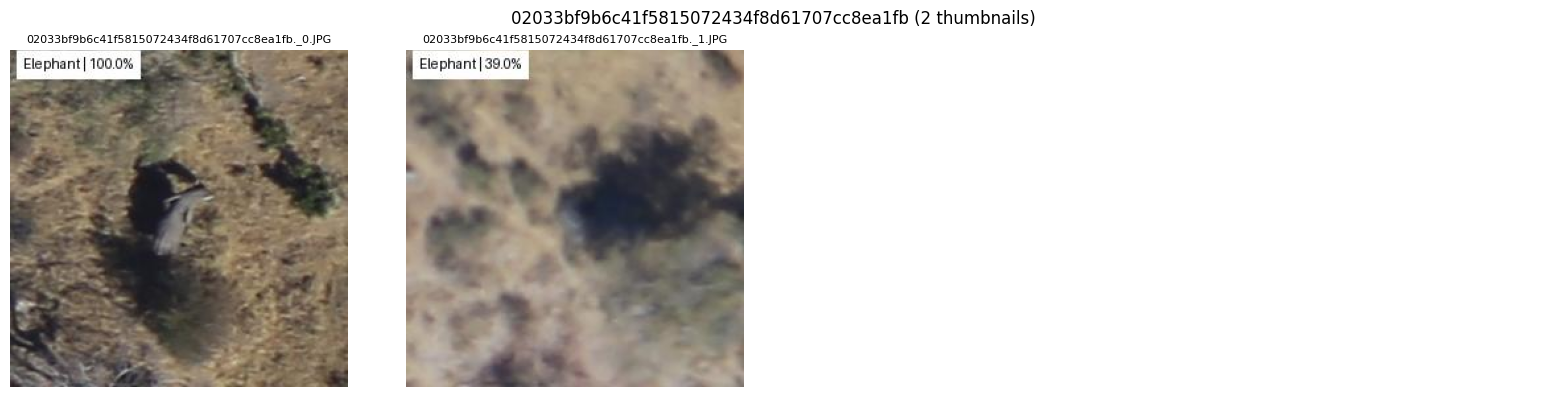

In [22]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# Image stem to plot
thumbnails_folder = Path("thumbnails")

# Find all thumbnails for this stem
thumbnails = sorted(thumbnails_folder.glob(f"{image_stem}._*.JPG"))

print(f"Found {len(thumbnails)} thumbnails")

# Plot all in a grid
n_cols = 4
n_rows = (len(thumbnails) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten() if len(thumbnails) > 1 else [axes]

for ax, thumb_path in zip(axes, thumbnails):
    img = Image.open(thumb_path)
    ax.imshow(img)
    ax.set_title(thumb_path.name, fontsize=8)
    ax.axis("off")

# Hide empty subplots
for ax in axes[len(thumbnails):]:
    ax.axis("off")

plt.suptitle(f"{image_stem} ({len(thumbnails)} thumbnails)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{image_stem}_thumbnails.png", dpi=150, bbox_inches="tight")

### Inspect Results Interactively
Using FiftyOne (https://voxel51.com/fiftyone) 

On your Desktop you can View Detections and Ground Truth interactively by using this command

python HerdNet/tools/view.py ./data/test_sample data/test_sample.csv -dets detections.csv

## Actual Training with a larger Dataset

Here we use the already trained model and fine tune it. In this case the model was already trained with the general dataset, so it just a academic example.
Since the dataset is very big it will take a while. A fairly cheap way of doing would be using a cloud Instance. runpod.io has been helpful for me.

Retrieve the Dataset https://dataverse.uliege.be/dataset.xhtml?persistentId=doi:10.58119/ULG/MIRUU5 

In [ ]:
data_path = hf_hub_download(
    repo_id="karisu/General_Dataset",
    repo_type="dataset",
    filename="general_dataset.zip",  # specify the file path within the repo
    local_dir="./data",
)
print(f"Downloaded path: {data_path}"}

In [33]:
from pathlib import Path
import zipfile

if not Path("./data/test").exists() or not Path("./data/train").exists():
    print("Extracting dataset...")
    with zipfile.ZipFile("./general_dataset.zip", "r") as zip_ref:
        zip_ref.extractall("./data")
    print("Done")
else:
    print("Dataset already extracted")


Dataset already extracted


### Manual Patch creation
Patch larger images into trainable tiles

In [35]:
# Create validation patches using the patcher tool (for demo)
from animaloc.utils.useful_funcs import mkdir
if not Path("./data/val_patches").exists():
    mkdir('./data/val_patches')
    !python ./HerdNet/tools/patcher.py ./data/val 512 512 0 ./data/val_patches -csv ./data/val.csv -min 0.0 -all False
else:
    print("Validation Patches already exist")

Validation Patches already exist


#### Load the Training and Validation Datasets

In [38]:
train_dataset = CSVDataset(
    csv_file = './data/train_patches.csv',
    root_dir = './data/train_patches',
    albu_transforms = [
        A.VerticalFlip(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.Normalize(p=1.0)
        ],
    end_transforms = [MultiTransformsWrapper([
        FIDT(num_classes=num_classes, down_ratio=down_ratio),
        PointsToMask(radius=2, num_classes=num_classes, squeeze=True, down_ratio=int(patch_size//16))
        ])]
    )

val_dataset = CSVDataset(
    csv_file = './data/val_patches/gt.csv',
    root_dir = './data/val_patches',
    albu_transforms = [A.Normalize(p=1.0)],
    end_transforms = [DownSample(down_ratio=down_ratio, anno_type='point')]
    )

In [39]:
train_dataloader = DataLoader(dataset = train_dataset, batch_size = 12, shuffle = True)

val_dataloader = DataLoader(dataset = val_dataset, batch_size = 1, shuffle = False)

In [40]:
evaluator = HerdNetEvaluator(
    model=herdnet,
    dataloader=val_dataloader,
    metrics=metrics,
    stitcher=stitcher,
    work_dir=work_dir,
    header='validation'
    )

In [41]:
lr = 1e-5
weight_decay = 1e-3
epochs = 2

In [42]:
trainer = Trainer(
    model=herdnet,
    train_dataloader=train_dataloader,
    optimizer=optimizer,
    num_epochs=epochs,
    evaluator=evaluator,
    work_dir=work_dir
    )

### Training
(about 15 minutes per epoch on RTX 4090 )

In [43]:
# Start the training, the Focal and Cross Entropy Loss should already be very low from the start.
trainer.start(warmup_iters=100, checkpoints='best', select='max', validate_on='f1_score')


[TRAINING] - Epoch: [1] [  1/648] eta: 0:18:42 lr: 0.000002 loss: 0.3664 (0.3664) focal_loss: 0.3336 (0.3336) ce_loss: 0.0329 (0.0329) time: 1.7319 data: 1.2675 max mem: 6158
[TRAINING] - Epoch: [1] [ 51/648] eta: 0:14:28 lr: 0.000051 loss: 0.2730 (0.2837) focal_loss: 0.2677 (0.2763) ce_loss: 0.0053 (0.0075) time: 1.4146 data: 1.2709 max mem: 6304
[TRAINING] - Epoch: [1] [101/648] eta: 0:13:09 lr: 0.000100 loss: 0.3254 (0.3055) focal_loss: 0.3210 (0.2990) ce_loss: 0.0046 (0.0066) time: 1.4153 data: 1.2588 max mem: 6305
[TRAINING] - Epoch: [1] [151/648] eta: 0:11:51 lr: 0.000100 loss: 0.3260 (0.3219) focal_loss: 0.3165 (0.3145) ce_loss: 0.0080 (0.0074) time: 1.3720 data: 1.2211 max mem: 6305
[TRAINING] - Epoch: [1] [201/648] eta: 0:10:33 lr: 0.000100 loss: 0.3375 (0.3344) focal_loss: 0.3345 (0.3251) ce_loss: 0.0095 (0.0092) time: 1.3755 data: 1.2300 max mem: 6305
[TRAINING] - Epoch: [1] [251/648] eta: 0:09:20 lr: 0.000100 loss: 0.4181 (0.3488) focal_loss: 0.4050 (0.3387) ce_loss: 0.0104

LossWrapper(
  (model): LossWrapper(
    (model): HerdNet(
      (base_0): DLA(
        (base_layer): Sequential(
          (0): Conv2d(3, 16, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
          (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (level0): Sequential(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (level1): Sequential(
          (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (level2): Tree(
          (tree1): BasicBlock(
            (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), paddi

### Evaluate the just trained model

In [ ]:
# Load trained parameters
from animaloc.models import load_model
pth_path = './output/best_model.pth'

herdnet_trained = load_model(herdnet, pth_path=pth_path)
herdnet_trained = LossWrapper(herdnet, losses=losses)

In [51]:
test_dataset = CSVDataset(
    csv_file = './data/test_sample.csv',
    root_dir = './data/test_sample',
    albu_transforms = [A.Normalize(p=1.0)],
    end_transforms = [DownSample(down_ratio=down_ratio, anno_type='point')]
    )


test_dataloader = DataLoader(dataset = test_dataset, batch_size = 1, shuffle = False)

In [52]:
# Create an Evaluator
test_evaluator = HerdNetEvaluator(
    model=herdnet_trained,
    dataloader=test_dataloader,
    metrics=metrics,
    stitcher=stitcher,
    work_dir=test_dir,
    header='test'
    )

In [53]:
# Print global F1 score (%)
test_f1_score = test_evaluator.evaluate(returns='f1_score')
print(f"F1 score = {test_f1_score * 100:0.0f}%")

test [1/7] eta: 0:00:42 n: 26 tp: 6 fp: 17 fn: 3 recall: 0.67 precision: 0.26 f1_score: 0.38 f2_score: 0.51 f5_score: 0.63 MAE: 14.0 ME: 181.0 MSE: 196.0 RMSE: 14.0 avg_score: 0.54 avg_dscore: 0.146 time: 6.0972 data: 0.6324 max mem: 6305
test [7/7] eta: 0:00:06 n: 19 tp: 11 fp: 7 fn: 1 recall: 0.92 precision: 0.61 f1_score: 0.73 f2_score: 0.83 f5_score: 0.9 MAE: 6.0 ME: 182.0 MSE: 36.0 RMSE: 6.0 avg_score: 0.79 avg_dscore: 0.174 time: 6.2521 data: 0.6443 max mem: 6305
test Total time: 0:00:43 (6.2527 s / it)
F1 score = 48%


/workspace/./HerdNet/animaloc/eval/metrics.py:338: RuntimeWarning: invalid value encountered in divide
  recalls = sorted_table[:,2] / n_gt


### Reproducable Training based on a Config
This training and inference can be based on the same configuration. This reduces the setup.

In [71]:
from animaloc.utils.train import main

# Clear any previous Hydra state (important in notebooks when re-running cells)
GlobalHydra.instance().clear()

# Configure paths
config_dir = str(Path("models/general_2022/").resolve())  # adjust as needed
config_name = "config"

# Load config
with initialize_config_dir(config_dir=config_dir, version_base="1.1"):
    cfg = compose(config_name=config_name, overrides=[
        # Add any overrides here, e.g.:
        "training_settings.epochs=1",
        "training_settings.batch_size=24",
        "model.load_from=models/general_2022/20220413_HerdNet_General_dataset_2022.pth",
        "datasets.train.csv_file=data/train_patches.csv",
        "datasets.train.root_dir=data/train_patches",
        "datasets.validate.csv_file=data/val_patches/gt.csv",
        "datasets.validate.root_dir=data/val_patches",
        "wandb_flag=true",
    ])

# Inspect config (optional)
# print(OmegaConf.to_yaml(cfg))

In [72]:
# Run training using 
result = main(cfg)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


/workspace/./HerdNet/animaloc/models/utils.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(pth_path, map_location=map_location)
/usr/local/lib/p

[TRAINING] - Epoch: [1] [  1/324] eta: 0:06:41 lr: 0.000001 loss: 0.3010 (0.3010) focal_loss: 0.2941 (0.2941) ce_loss: 0.0069 (0.0069) time: 1.2378 data: 0.9181 max mem: 13047
[TRAINING] - Epoch: [1] [226/324] eta: 0:00:32 lr: 0.000070 loss: 0.3383 (0.3132) focal_loss: 0.3343 (0.3067) ce_loss: 0.0057 (0.0065) time: 0.3159 data: 0.0279 max mem: 13047
[TRAINING] - Epoch: [1] [324/324] eta: 0:00:00 lr: 0.000100 loss: 0.3464 (0.3260) focal_loss: 0.3389 (0.3185) ce_loss: 0.0074 (0.0075) time: 0.3123 data: 0.0292 max mem: 13047
[TRAINING] - Epoch: [1] Total time: 0:01:44 (0.3213 s / it)
[VALIDATION] - Epoch: [1] [  1/532] eta: 0:21:07 n: 1 tp: 1 fp: 0 fn: 0 recall: 1.0 precision: 1.0 f1_score: 1.0 f2_score: 1.0 f5_score: 1.0 MAE: 0.0 ME: 0.0 MSE: 0.0 RMSE: 0.0 avg_score: 1.0 avg_dscore: 0.296 time: 2.3825 data: 0.0308 max mem: 13047
[VALIDATION] - Epoch: [1] [126/532] eta: 0:01:38 n: 4 tp: 1 fp: 2 fn: 1 recall: 0.5 precision: 0.33 f1_score: 0.4 f2_score: 0.45 f5_score: 0.49 MAE: 1.0 ME: 0.0 

accuracy,▁
avg_dscores,▁
avg_scores,▁
ce_loss,▄▂▃▄▃▂▂▂▂▃▃▂▃▃▃▃▂▂▂▂▂▁▂▃▂▂▁▄▂▁▅▂▆▃▄▂█▂▂▄
density/1/f1,▁
density/1/f2,▁
density/1/fn,▁
density/1/fp,▁
density/1/mae,▁
density/1/precision,▁
+51,...


/workspace/./HerdNet/animaloc/utils/train.py:405: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pth_file = torch.load(path)


### Visualisation
#### Training Data
![Augmented Example](./visualizations/augmented_dataset_example_3.png)

#### Heatmap on Validation
![Heatmap](./visualizations/heatmap_overlay_005c952ba7a612c40986806cc84a87e1573ef4f2_14.JPG_1.png)

#### Heatmap and Ground Truth
![Heatmap](./visualizations/heatmap_target_005c952ba7a612c40986806cc84a87e1573ef4f2_14.JPG_1.png)